In [18]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Train model

In [ ]:
# Load a base model (choose one)
model = YOLO("../Weights/yolov8n.pt") 
# Train 
results = model.train(
    # Path to your dataset YAML file (should contain paths to train/val images and class names)
    data=r"D:\Projects\03-YOLOobject-tracking\Datasets\constructionSafetySet\ppe_data.yaml",
    epochs=2,
    imgsz=640,
    batch=8,
    name="ppe_training",       # saved under runs/detect/ppe_training/
    project="D:\\Projects\\03-YOLOobject-tracking\\runs",
    device='cpu',              # 0 = GPU, 'cpu' = CPU
    workers=4,
    patience=10,               # early stopping if no improvement for 10 epochs
    save=True,
    plots=True,                # saves training plots (loss, mAP curves)
)

print("Training complete!")
print(f"Best weights saved at: {results.save_dir}/weights/best.pt")

# Test model

In [ ]:
# switch to the best.pt file from your training results
model = YOLO("../runs/ppe_training/weights/best.pt") 
print(f"YOLO is running on: {model.device}") 

# Predict on an image
results = model.predict(
    source="D:\\Projects\\03-YOLOobject-tracking\\Images\\pp02.jpg", 
    conf=0.25, 
    save=False,
)
show = results[0].plot()

YOLO is running on: cpu

image 1/1 D:\Projects\03-YOLOobject-tracking\Images\pp02.jpg: 640x640 1 Hardhat, 1 Mask, 1 Person, 1 Safety Vest, 56.5ms
Speed: 6.1ms preprocess, 56.5ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 640)


# Plot

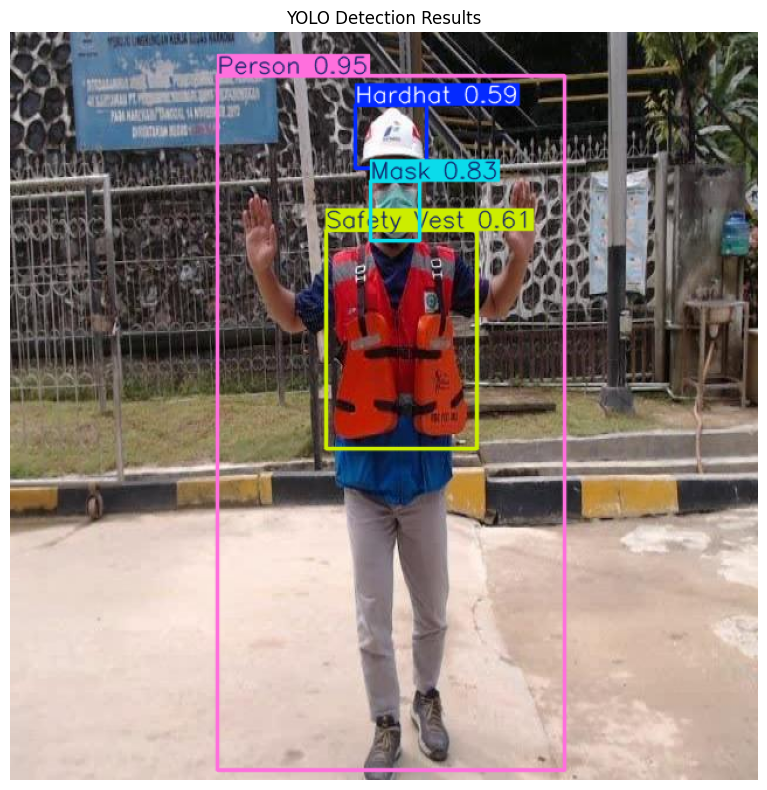

In [44]:
show_rgb = cv2.cvtColor(show, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(show_rgb)
plt.axis("off")
plt.title("YOLO Detection Results")
plt.tight_layout()
plt.show()